In [2]:
import pandas as pd
import requests
from Bio import SeqIO
from io import StringIO

In [22]:
df = pd.read_csv('condensation_starter_dataset_philmuslab.csv')
df.columns

Index(['accession', 'category', 'size_carbons', 'size_cno', 'cond_accession',
       'type', 'aa_seq'],
      dtype='object')

In [ ]:
df_entries = df[['category', 'accession']].dropna()
mibig_full_tax = {}
mibig_acc_tax = {}
for acc in df_entries['accession']:
    #print(i)
    #acc = df.at[i,'entry_accession']
    print(acc)
    r = requests.get("https://mibig.secondarymetabolites.org/repository/" + acc + "/" + acc +".gbk").text
    record = SeqIO.read(StringIO(r), "genbank")
    taxonomy = record.annotations.get('taxonomy', [])
    organism = record.annotations.get('organism', 'Unknown')
    
    print(f"Organism: {organism}", acc)
    print("Taxonomy:")
    print(" > ".join(taxonomy))
    print(taxonomy)
    mibig_full_tax[acc] = taxonomy


    if 'Bacteria' in taxonomy:
        print("This is a bacterial sequence.")
        mibig_acc_tax[acc] = 'bacteria'
        

    elif 'Fungi' in taxonomy:
        print("This is a fungal sequence.")
        mibig_acc_tax[acc] = 'fungi'

    else:
        print("This sequence is neither bacterial nor fungal, or the information is not available.")
        mibig_acc_tax[acc] = 'unknown'
    print()

In [24]:
for i in range(len(df)):
    if df.at[i, 'accession'] in mibig_full_tax:
        df.at[i, 'full_tax'] = str(mibig_full_tax[df.at[i, 'accession']])
        df.at[i, 'basic_tax'] = str(mibig_acc_tax[df.at[i, 'accession']])
df

,accession,category,size_carbons,size_cno,cond_accession,type,aa_seq,full_tax,basic_tax
0,BGC0000084,NaN,NaN,NaN,COND0000084-ladG,Condensation_Starter,MERRLGAHEMALYRSGGRVLVPCEIEGDVDRALLAEALRILTEFHP...,NaN,NaN
1,BGC0000126,NaN,NaN,NaN,COND0000126-pldC,Condensation_Starter,MALCTVRGDTNEQLLQRAFASSVAAHPSLRSRISPDGTELVLHPLD...,NaN,NaN
2,BGC0000141,NaN,NaN,NaN,COND0000141-rubF3,Condensation_Starter,MRRRIARSERMYVSEIRTQALQICVVRGGVDAGILDAAFTAVLAEA...,NaN,NaN
3,BGC0000291,LCFA,NaN,NaN,COND0000291-lptA,Condensation_Starter,MLESSAHRVAATSAQTGIWTAQRLRGDDRLYACGLFLELDHVVEEV...,"['Bacteria', 'Actinobacteria', 'Streptomycetal...",bacteria
4,BGC0000296,AR,8.0,11.0,COND0000296-acmB,Condensation_Starter,MFVRPDAELPLTAAQREIWIAEQRLGKRNRVFRVGEYLEIHGRVDL...,"['Bacteria', 'Actinobacteria', 'Streptomycetal...",bacteria
...,...,...,...,...,...,...,...,...,...
223,BGC0002695,AR,7.0,10.0,COND0002695-HOO54_19915,Condensation_Starter,MTKCPNNGKRLTGAQAGIWFAQQLDPENPIYNTGEYVEIHGSIDPQ...,NaN,NaN
224,BGC0002696,AR,7.0,10.0,COND0002696-AWH04_05480,Condensation_Starter,PGLNSGAASEATFALTGAQLGIWNAQRLDPESRSYLVGEVLEISGD...,NaN,NaN
225,BGC0002697,LCFA,10.0,11.0,COND0002697-SCATT_32630,Condensation_Starter,MAHALFPELPQFNLFLARRFTGPVDAARLAQCLREAAGRNDAFGLR...,NaN,NaN
226,BGC0002719,LCFA,10.0,12.0,COND0002719-G7W60_10810,Condensation_Starter,MIEPRCFSLSSTQQSVWFDQLLSPDTPSYNIGVTVQIDGAVDPAIF...,NaN,NaN


In [ ]:
df.to_csv('cs_data_withtax.csv', index=False)


In [3]:
df_tax = pd.read_csv('cs_data_withtax.csv')

In [6]:
df_tax

,accession,category,size_carbons,size_cno,cond_accession,type,aa_seq,full_tax,basic_tax
3,BGC0000291,LCFA,NaN,NaN,COND0000291-lptA,Condensation_Starter,MLESSAHRVAATSAQTGIWTAQRLRGDDRLYACGLFLELDHVVEEV...,"['Bacteria', 'Actinobacteria', 'Streptomycetal...",bacteria
4,BGC0000296,AR,8.0,11.0,COND0000296-acmB,Condensation_Starter,MFVRPDAELPLTAAQREIWIAEQRLGKRNRVFRVGEYLEIHGRVDL...,"['Bacteria', 'Actinobacteria', 'Streptomycetal...",bacteria
5,BGC0000305,LCFA,10.0,12.0,COND0000305-arfA,Condensation_Starter,PAVATPSASLQTYPLTAAQLDIWLDQLSRGDSPLYNIGGYLDLSGP...,"['Bacteria', 'Proteobacteria', 'Gammaproteobac...",bacteria
6,BGC0000306,LCFA,16.0,17.0,COND0000306-SSIG_07966,Condensation_Starter,MSASPDRQLALTSAQTGMWLAQRFAADRLDYSIAQYVEIRGPLDTG...,"['Bacteria', 'Actinobacteria', 'Streptomycetal...",bacteria
7,BGC0000309,AR,7.0,10.0,COND0000309-BSU_31960,Condensation_Starter,MPDTKDLQYSLTGAQTGIWFAQQLDPDNPIYNTAEYIEINGPVNIA...,"['Bacteria', 'Firmicutes', 'Bacilli', 'Bacilla...",bacteria
...,...,...,...,...,...,...,...,...,...
223,BGC0002695,AR,7.0,10.0,COND0002695-HOO54_19915,Condensation_Starter,MTKCPNNGKRLTGAQAGIWFAQQLDPENPIYNTGEYVEIHGSIDPQ...,"['Bacteria', 'Firmicutes', 'Bacilli', 'Bacilla...",bacteria
224,BGC0002696,AR,7.0,10.0,COND0002696-AWH04_05480,Condensation_Starter,PGLNSGAASEATFALTGAQLGIWNAQRLDPESRSYLVGEVLEISGD...,"['Bacteria', 'Actinobacteria', 'Corynebacteria...",bacteria
225,BGC0002697,LCFA,10.0,11.0,COND0002697-SCATT_32630,Condensation_Starter,MAHALFPELPQFNLFLARRFTGPVDAARLAQCLREAAGRNDAFGLR...,"['Bacteria', 'Actinobacteria', 'Streptomycetal...",bacteria
226,BGC0002719,LCFA,10.0,12.0,COND0002719-G7W60_10810,Condensation_Starter,MIEPRCFSLSSTQQSVWFDQLLSPDTPSYNIGVTVQIDGAVDPAIF...,"['Bacteria', 'Proteobacteria', 'Gammaproteobac...",bacteria


In [4]:
df_tax = df_tax.dropna(subset=['category'])


In [10]:
def tax_level(entry, level):
    if entry == '[]':
        return None
    try:
        s = entry[1:-1].split(', ')
    except:
        return None
    if level >= len(s):
        return None
    return s[level][1:-1]

category = 'tax'
inspect = 'category'
level = 1
filter = False
filter_cat = 'Actinobacteria'
filter_level = 1

analysis_df = pd.DataFrame()
analysis_df['inspect'] = df_tax[inspect]



if category == 'tax':
    analysis_df['category'] = df_tax['full_tax'].apply(lambda x: tax_level(x, level=level))
    if filter == True:
        analysis_df['filter_cat']= df_tax['full_tax'].apply(lambda x: tax_level(x, level=filter_level))
        analysis_df = analysis_df[analysis_df['filter_cat'] == filter_cat]
else:
    analysis_df['category'] = df_tax[category]

analysis_df.dropna()

set(analysis_df['category'].values)


{'Actinobacteria',
 'Bacteroidetes',
 'Cyanobacteria',
 'Firmicutes',
 'Proteobacteria',
 'Verrucomicrobia',
 'environmental samples'}

In [16]:
def tax_level(entry, level):
    if entry == '[]':
        return None
    try:
        s = entry[1:-1].split(', ')
    except:
        return None
    if level >= len(s):
        return None
    return s[level][1:-1]

category = 'tax'
inspect = 'category'
level = 4
filter = False
filter_cat = 'Actinobacteria'
filter_level = 1

analysis_df = pd.DataFrame()
analysis_df['inspect'] = df_tax[inspect]

levels_save = []

for level in range(-1,5):
    analysis_df = pd.DataFrame()
    analysis_df['inspect'] = df_tax[inspect]
    
    levels_save.append({})
    analysis_df['category'] = df_tax['full_tax'].apply(lambda x: tax_level(x, level=max(level, 0)))
    #analysis_df['filter_cat']= df_tax['full_tax'].apply(lambda x: tax_level(x, level=filter_level))
    #analysis_df = analysis_df[analysis_df['filter_cat'] == filter_cat]

    analysis_df.dropna()

    filter_cats = set(analysis_df['category'].values)
    for filter_cat in filter_cats:
        analysis_df = pd.DataFrame()
        analysis_df['inspect'] = df_tax[inspect]

        analysis_df['category'] = df_tax['full_tax'].apply(lambda x: tax_level(x, level=level+1))
        analysis_df['filter_cat']= df_tax['full_tax'].apply(lambda x: tax_level(x, level=max(level, 0)))
        analysis_df = analysis_df[analysis_df['filter_cat'] == filter_cat]

        for category in set(analysis_df['category'].values):
            #print(filter_cat, category)
            #print(dict(analysis_df[analysis_df['category'] == category]['inspect'].value_counts()))

            levels_save[level][category] = {'supercategory': filter_cat,
                                            'values': dict(analysis_df[analysis_df['category'] == category]['inspect'].value_counts())}

    analysis_df.dropna()
    

levels_save

[{'Bacteria': {'supercategory': 'Bacteria',
   'values': {'LCFA': 69, 'AR': 67, 'SCFA': 33, 'MCFA': 28, 'FA': 4}},
  'unclassified sequences': {'supercategory': 'unclassified sequences',
   'values': {'FA': 1}},
  'Firmicutes': {'supercategory': 'Bacteria',
   'values': {'MCFA': 10, 'LCFA': 7, 'AR': 4, 'SCFA': 1, 'FA': 1}},
  'Proteobacteria': {'supercategory': 'Bacteria',
   'values': {'LCFA': 40, 'AR': 26, 'SCFA': 14, 'MCFA': 9, 'FA': 3}},
  'Actinobacteria': {'supercategory': 'Bacteria',
   'values': {'AR': 37, 'LCFA': 17, 'SCFA': 16, 'MCFA': 7}},
  'environmental samples': {'supercategory': 'unclassified sequences',
   'values': {'FA': 1}},
  'Bacteroidetes': {'supercategory': 'Bacteria', 'values': {'SCFA': 1}},
  'Cyanobacteria': {'supercategory': 'Bacteria', 'values': {'LCFA': 2}},
  'Verrucomicrobia': {'supercategory': 'Bacteria',
   'values': {'SCFA': 1, 'MCFA': 1}}},
 {'Clostridia': {'supercategory': 'Firmicutes', 'values': {'MCFA': 1}},
  'Bacilli': {'supercategory': 'Firmicu

In [12]:
def f(levels_save, level, supercat, of):
    current = levels_save[level]
    for category in current:
        if supercat == current[category]['supercategory']:
            spaces = '      ' * level
            if current[category]['values'] != {}:
                ar = current[category]['values'].get('AR', 0)
                scfa = current[category]['values'].get('SCFA', 0)
                mcfa = current[category]['values'].get('MCFA', 0)
                lcfa = current[category]['values'].get('LCFA', 0)
                p_ar = current[category]['values'].get('AR', '')
                p_scfa = current[category]['values'].get('SCFA', '')
                p_mcfa = current[category]['values'].get('MCFA', '')
                p_lcfa = current[category]['values'].get('LCFA', '')
                
                print(spaces,category, current[category]['values'])
                of.write(spaces + category + ',' + f"{str(p_ar)},{str(p_scfa)},{str(p_mcfa)},{str(p_lcfa)}\n")
                if ar+scfa+mcfa+lcfa > 20:
                    f(levels_save, level + 1, category, of)

with open('phylo_2.csv', 'w') as of:
    f(levels_save, 0, 'Bacteria', of)

 Bacteria {'LCFA': 69, 'AR': 67, 'SCFA': 33, 'MCFA': 28, 'FA': 4}
 Firmicutes {'MCFA': 10, 'LCFA': 7, 'AR': 4, 'SCFA': 1, 'FA': 1}
       Clostridia {'MCFA': 1}
       Bacilli {'MCFA': 9, 'LCFA': 7, 'AR': 4, 'SCFA': 1, 'FA': 1}
             Bacillales {'MCFA': 9, 'LCFA': 7, 'AR': 4, 'SCFA': 1, 'FA': 1}
                   Paenibacillaceae {'MCFA': 9, 'LCFA': 2, 'AR': 1, 'SCFA': 1, 'FA': 1}
                   Bacillaceae {'LCFA': 5, 'AR': 3}
 Proteobacteria {'LCFA': 40, 'AR': 26, 'SCFA': 14, 'MCFA': 9, 'FA': 3}
       Betaproteobacteria {'LCFA': 8, 'SCFA': 6, 'AR': 3, 'MCFA': 2, 'FA': 2}
       Deltaproteobacteria {'AR': 3}
       Epsilonproteobacteria {'MCFA': 1}
       Alphaproteobacteria {'LCFA': 2, 'FA': 1, 'AR': 1}
       Gammaproteobacteria {'LCFA': 30, 'AR': 19, 'SCFA': 8, 'MCFA': 6}
             Moraxellales {'AR': 1}
             Aeromonadales {'AR': 1}
             Pseudomonadales {'LCFA': 26, 'AR': 5, 'SCFA': 4, 'MCFA': 2}
                   Pseudomonadaceae {'LCFA': 26, 'AR':

In [13]:
def f(levels_save, level, supercat, of):
    current = levels_save[level]
    for category in current:
        if supercat == current[category]['supercategory']:
            spaces = '  ' * level
            if current[category]['values'] != {}:
                ar = current[category]['values'].get('AR', 0)
                scfa = current[category]['values'].get('SCFA', 0)
                mcfa = current[category]['values'].get('MCFA', 0)
                lcfa = current[category]['values'].get('LCFA', 0)
                print(spaces +'{')
                print(spaces + '"name": "' +category + '",')
                print(spaces + '"value": ' + str(ar+scfa+mcfa+lcfa) + ',')
                print(spaces + '"values": ' + '{"AR": ' +str(ar) + ', "SCFA": ' + str(scfa) + ', "MCFA": ' + str(mcfa) + ', "LCFA": ' + str(lcfa) + '},')
                print(spaces +' "children": [')
                f(levels_save, level + 1, category, of)
                print(spaces +' ]')
                print(spaces +'},')


f(levels_save, 0, 'Bacteria', of)

{
"name": "Bacteria",
"value": 197,
"values": {"AR": 67, "SCFA": 33, "MCFA": 28, "LCFA": 69},
 "children": [
 ]
},
{
"name": "Firmicutes",
"value": 22,
"values": {"AR": 4, "SCFA": 1, "MCFA": 10, "LCFA": 7},
 "children": [
  {
  "name": "Clostridia",
  "value": 1,
  "values": {"AR": 0, "SCFA": 0, "MCFA": 1, "LCFA": 0},
   "children": [
    {
    "name": "Eubacteriales",
    "value": 1,
    "values": {"AR": 0, "SCFA": 0, "MCFA": 1, "LCFA": 0},
     "children": [
      {
      "name": "Clostridiaceae",
      "value": 1,
      "values": {"AR": 0, "SCFA": 0, "MCFA": 1, "LCFA": 0},
       "children": [
        {
        "name": "Clostridium",
        "value": 1,
        "values": {"AR": 0, "SCFA": 0, "MCFA": 1, "LCFA": 0},
         "children": [
         ]
        },
       ]
      },
     ]
    },
   ]
  },
  {
  "name": "Bacilli",
  "value": 21,
  "values": {"AR": 4, "SCFA": 1, "MCFA": 9, "LCFA": 7},
   "children": [
    {
    "name": "Bacillales",
    "value": 21,
    "values": {"AR": 4, 

TypeError: 'Axes' object is not iterable

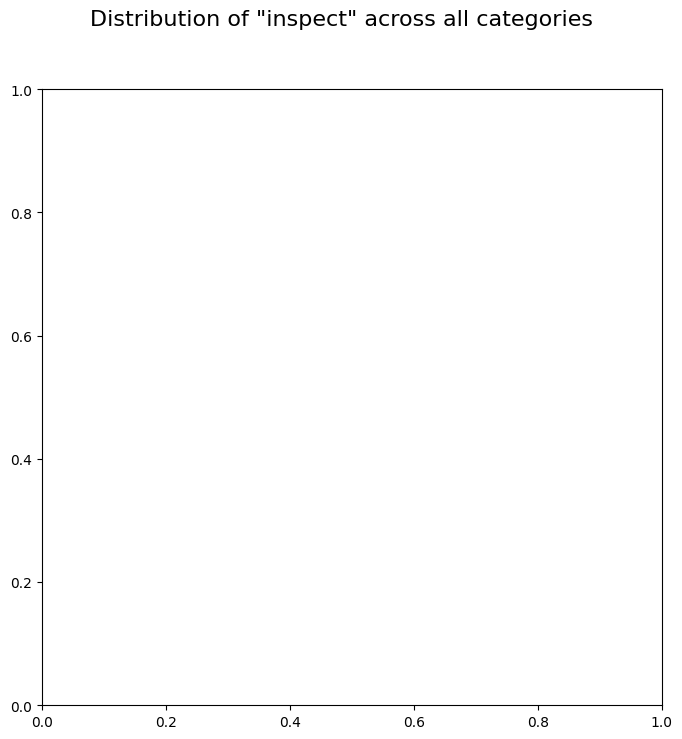

In [14]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_category_pie(category_data, category_name):
    inspect_counts = category_data['inspect'].value_counts()
    plt.figure(figsize=(10, 8))
    patches, texts, autotexts = plt.pie(inspect_counts.values, labels=inspect_counts.index, autopct='%1.1f%%')
    plt.title(f'Distribution of "inspect" for category {category_name}')
    
    legend_labels = [f'{index} ({count})' for index, count in inspect_counts.items()]
    plt.legend(patches, legend_labels, title="Inspect (Count)", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    print(f"\nCounts for category {category_name}:")
    for index, count in inspect_counts.items():
        print(f"{index}: {count}")


grouped = analysis_df.groupby('category')

for category, data in grouped:
    plot_category_pie(data, category)

def plot_all_categories(df):
    categories = df['category'].unique()
    n_categories = len(categories)
    
    fig, axes = plt.subplots(1, n_categories, figsize=(8*n_categories, 8))
    fig.suptitle('Distribution of "inspect" across all categories', fontsize=16)
    
    for ax, (category, data) in zip(axes, grouped):
        inspect_counts = data['inspect'].value_counts()
        patches, texts, autotexts = ax.pie(inspect_counts.values, labels=inspect_counts.index, autopct='%1.1f%%')
        ax.set_title(f'Category {category}')
        
        legend_labels = [f'{index} ({count})' for index, count in inspect_counts.items()]
        ax.legend(patches, legend_labels, title="Inspect (Count)", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
        
        ax.axis('equal')
    
    plt.tight_layout()
    plt.show()
    
    print("\nCounts for all categories:")
    for category, data in grouped:
        inspect_counts = data['inspect'].value_counts()
        print(f"\nCategory {category}:")
        for index, count in inspect_counts.items():
            print(f"{index}: {count}")

plot_all_categories(analysis_df)

In [ ]:
import json
import plotly.graph_objects as go

with open('phylo.json', 'r') as f:
    phylo_data = json.load(f)

def extract_sunburst_data(data, parent="", min_count=5):
    """
    Extract data for sunburst plot from hierarchical JSON structure,
    filtering to only include nodes with min_count or more examples.
    Only includes leaf nodes if they have min_count or more examples.
    """
    ids = []
    labels = []
    parents = []
    values = []
    
    for item in data:
        if item['value'] >= min_count:
            current_id = f"{parent}/{item['name']}" if parent else item['name']
            
            ids.append(current_id)
            labels.append(item['name'])
            parents.append(parent)
            values.append(item['value'])

            if item.get('children') and len(item['children']) > 0:
                qualifying_children = [child for child in item['children'] if child['value'] >= min_count]
                
                if qualifying_children:
                    child_ids, child_labels, child_parents, child_values = extract_sunburst_data(
                        qualifying_children, current_id, min_count
                    )
                    ids.extend(child_ids)
                    labels.extend(child_labels)
                    parents.extend(child_parents)
                    values.extend(child_values)
    
    return ids, labels, parents, values

ids, labels, parents, values = extract_sunburst_data(phylo_data, min_count=5)

fig = go.Figure(go.Sunburst(
    ids=ids,
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total",
    hovertemplate='<b>%{label}</b><br>Total Count: %{value}<br>Percentage: %{percentParent}<extra></extra>',
    maxdepth=5,
    textfont_size=14,
))

fig.update_layout(
    title="Phylogenetic Distribution Sunburst Plot (Taxa with ≥5 Examples Only)",
    title_x=0.5,
    width=900,
    height=900,
    font_size=16,
    title_font_size=18
)

fig.show(renderer="browser")

print(f"Sunburst plot includes {len(ids)} taxa (all with ≥5 examples):")
print("\nIncluded taxa:")
for i, (label, value, parent) in enumerate(zip(labels, values, parents)):
    indent = "  " * (parent.count('/') if parent else 0)
    print(f"{indent}{label}: {value}")


Sunburst plot includes 29 taxa (all with ≥5 examples):

Included taxa:
Proteobacteria: 89
Gammaproteobacteria: 63
  Vibrionales: 5
    Vibrionaceae: 5
      Vibrio: 5
  Enterobacterales: 13
    Morganellaceae: 10
      Xenorhabdus: 8
  Pseudomonadales: 37
    Pseudomonadaceae: 37
      Pseudomonas: 34
Betaproteobacteria: 19
  Burkholderiales: 16
    Burkholderiaceae: 12
      Burkholderia: 6
Actinobacteria: 77
Streptomycetales: 54
  Streptomycetaceae: 54
    Streptomyces: 53
Corynebacteriales: 6
Pseudonocardiales: 8
  Pseudonocardiaceae: 8
Firmicutes: 22
Bacilli: 21
  Bacillales: 21
    Paenibacillaceae: 13
      Paenibacillus: 10
    Bacillaceae: 8
      Bacillus: 7
